# Text Classification Using Various Models with Movie Reviews from IMDB

In [224]:
# Install the following packages if you do not have them
!pip install pandas numpy vaderSentiment textblob matplotlib seaborn bs4 contractions
!pip install scikit-learn
!pip install nltk rank_bm25 gensim sentence-transformers
!pip install tf-keras

In [225]:
from bs4 import BeautifulSoup

# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import nltk
from nltk.corpus import stopwords
import contractions

# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from rank_bm25 import BM25Okapi

#Why is this one having an error?
#import gensim.downloader as api


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    hamming_loss, jaccard_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
import time
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# Download NLTK data
nltk.download('stopwords', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


#STEP 1: Choose Dataset

Dataset: IMDB Dataset of 50K Movie Reviews

This dataset contains only the review of the movies and the sentiment that the review is dictated to have. We are going to use the sentiment column to compare the results we get from the model.

In [227]:
movie_review_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment2\data\raw\IMDB Dataset.csv", header=0, encoding="utf-8")
movie_review_df

,review,sentiment
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive
...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative
49998,I'm going to have to disagree with the previous comment and side with Maltin on this one. This i...,negative


STEP 2: Exploring the Dataset

This includes finding out what the dataset is made up of, where there is missing data information, the data types of the columns in the dataset, and the overall distribution of the reviews and sentiments.

There are 50000 in this dataset


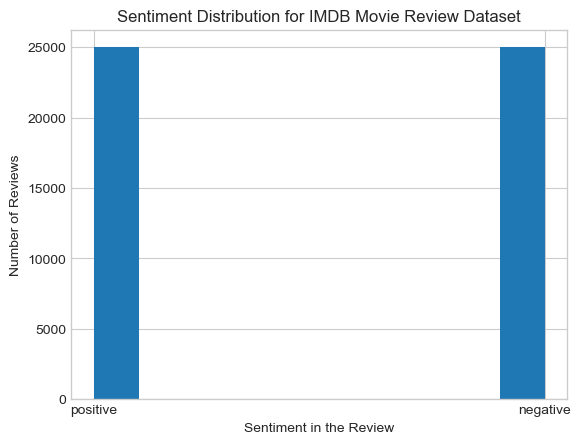

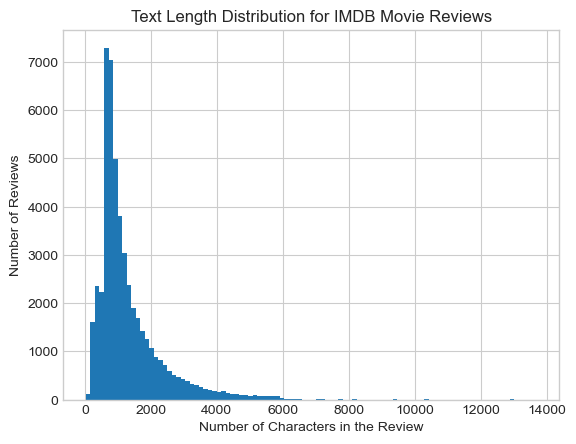

In [229]:
#2.1 Metadata of the Dataset

#2.1.1 Number of rows
#Store the number of rows in a variable
num_rows=len(movie_review_df)

#Print the clear number
print(f"There are {num_rows} in this dataset")

#2.1.2 Columns
movie_review_df.columns
#Column 1 ("review"): This column is made up of strings that are comprised of reviews

#Column 2 ("sentiment"): This column is comprised of strings that either read positive or negative.
movie_review_df['sentiment'].unique()

#2.1.3 Data Types
movie_review_df.dtypes
#Column 1 ("review"): This column is made up of strings
#Column 2 ("sentiment"): This column as it sits right now is made up of strings. If we looked at the code and made some slight adjustments it could be a boolean.

#2.1.4 Missing Values

#There are no missing values in this dataset.
movie_review_df.isna().sum()

#2.1.5 Target Distribution????

#2.2 Class Distribution

#Show a histogram for the distribution of the Sentiment reviews
plt.hist(movie_review_df['sentiment'])
plt.xlabel("Sentiment in the Review")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution for IMDB Movie Review Dataset")
#Save the Figure as a .png file
#plt.savefig("sentiment_distribution_hist.png")
plt.show()

#2.1.1 Is the dataset balanced?

#Shows a histogram for the length of the reviews in characters
#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=movie_review_df["review"].str.len()
#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for IMDB Movie Reviews")
#Save the Figure as a .png file
#plt.savefig("text_length_distribution_hist.png")
plt.show()

#Looking at the distribution of review sentiment from the sentiment column, we can see that the distribution is exactly even.



In [230]:
stop_words_nltk

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [231]:
# STEP 3: Pre-Processing

# =============================================================================
# DATA CLEANING FUNCTION
# =============================================================================

def clean_text_total(text):
    """
    Clean raw text by removing noise.
    
    Steps:
        1. Remove HTML tags (e.g., <p>, <div>, <br>)
        2. Remove URLs (http://, https://, www.)
        3. Remove email addresses
        4. Normalize whitespace (multiple spaces → single space)
    
    Parameters:
        text (str): Raw text string
    
    Returns:
        str: Cleaned text string
    
    Example:
        >>> clean_text("<p>Visit http://example.com or email test@mail.com</p>")
        'Visit or email'
    """
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Step 1: Remove HTML tags
    # Pattern: <anything> where anything doesn't contain >
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 2: Remove URLs
    # Pattern: http(s):// or www. followed by non-whitespace
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Step 3: Remove email addresses
    # Pattern: something@something.something
    text = re.sub(r'\S+@\S+', '', text)

    #Step 4: Catch any additional HTML that didn't make it through the initial cleaning steps.
    text= BeautifulSoup(text, "html.parser").get_text()
    
    # Step 4: Normalize whitespace
    # Replace multiple spaces/tabs/newlines with single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Expand contractions
    text=contractions.fix(text)

    #Removes Special Characters
    text=re.sub(r'[^a-zA-Z0-9. !?]', ' ', text)
    
    return text

In [240]:
movie_review_df['all_in_one_clean']=movie_review_df['review'].apply(clean_text_total)

In [241]:
movie_review_df

,review,sentiment,all_in_one_clean
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive,One of the other reviewers has mentioned that after watching just 1 Oz episode you will be hooke...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive,A wonderful little production. The filming technique is very unassuming very old time BBC fashi...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative,Basically there is a family where a little boy Jake thinks there is a zombie in his closet h...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive,Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei off...
...,...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive,I thought this movie did a down right good job. It was not as creative or original as the first ...
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative,Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ...
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative,I am a Catholic taught in parochial elementary schools by nuns taught by Jesuit priests in high...
49998,I'm going to have to disagree with the previous comment and side with Maltin on this one. This i...,negative,I am going to have to disagree with the previous comment and side with Maltin on this one. This ...


In [246]:
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer
#
stop_words_nltk = list(stopwords.words('english')) #define English as the stop words

movie_review_df['clean_review_wo_stopwords']=movie_review_df['all_in_one_clean'].copy()

for review in range(0, len(movie_review_df)):
    a = movie_review_df.clean_review_wo_stopwords[review].split()
    sentence=[ x for x in a  if x.casefold() not in stop_words_nltk]
    movie_review_df['clean_review_wo_stopwords'][review]=" ".join(sentence)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [250]:
print(movie_review_df['review'][0])
print(movie_review_df['clean_review_wo_stopwords'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [252]:
positive_cases=movie_review_df[movie_review_df['sentiment']=='positive']
negative_cases=movie_review_df[movie_review_df['sentiment']=='negative']

In [310]:
words_positive=negative_cases['clean_review_wo_stopwords'].str.split()
all_words_positive=words_positive.explode()
all_words_standard_positive=all_words_positive.str.lower()
word_counts_positive=all_words_standard_positive.value_counts()
top_n_words_posiitive=word_counts_positive.index[:10].tolist()

In [294]:
def most_popular_words(dataframe):
    words=dataframe['clean_review_wo_stopwords'].str.split()
    all_words=words.explode()
    all_words_standard=all_words.str.lower()
    word_counts=all_words_standard.value_counts()
    top_n_words=word_counts.index[:10]
    return top_n_words


print(f'The average number of characters in a postive review is {positive_cases['review'].str.len().mean()} characters.')
print(f'The average number of characters in a negative review is {negative_cases['review'].str.len().mean()} characters.')
print(f'The top 10 most popular words in positive reviews are {', '.join(most_popular_words(positive_cases))}.')
print(f'The top 10 most popular words in negative reviews are {', '.join(most_popular_words(negative_cases))}.')

The average number of characters in a postive review is 1324.79768 characters.
The average number of characters in a negative review is 1294.06436 characters.
The top 10 most popular words in positive reviews are film, movie, one, like, good, would, great, see, story, ..
The top 10 most popular words in negative reviews are movie, film, one, like, would, even, good, bad, really, could.


In [312]:
word_counts_positive.head(12)

clean_review_wo_stopwords
movie     41531
film      31736
one       24057
like      22121
would     17932
even      15007
good      13403
bad       12646
really    11989
could     11312
.         11231
see       10380
Name: count, dtype: int64

In [209]:
movie_review_df

,review,sentiment,review_wo_stopwords,clean_reviews,all_in_one_clean,all_in_one_clean_wo_sw
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive,"One reviewers mentioned watching 1 Oz episode hooked. right, exactly happened me.<br /><br />The...",One of the other reviewers has mentioned that after watching just 1 Oz episode you ll be hooked....,One of the other reviewers has mentioned that after watching just 1 Oz episode you will be hooke...,One reviewers mentioned watching 1 Oz episode hooked. right exactly happened me.The first thing...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive,wonderful little production. <br /><br />The filming technique unassuming- old-time-BBC fashion ...,A wonderful little production. The filming technique is very unassuming very old time BBC fashio...,A wonderful little production. The filming technique is very unassuming very old time BBC fashi...,wonderful little production. The filming technique unassuming old time BBC fashion gives comfor...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive,"thought wonderful way spend time hot summer weekend, sitting air conditioned theater watching li...",I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air ...,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching li...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative,Basically there's family little boy (Jake) thinks there's zombie closet & parents fighting time....,Basically there s a family where a little boy Jake thinks there s a zombie in his closet his par...,Basically there is a family where a little boy Jake thinks there is a zombie in his closet h...,Basically there is family little boy Jake thinks there is zombie closet parents fighting tim...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive,"Petter Mattei's ""Love Time Money"" visually stunning film watch. Mr. Mattei offers us vivid portr...",Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei offer...,Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei off...,Petter Mattei s Love Time Money visually stunning film watch. Mr. Mattei offers us vivid portr...
...,...,...,...,...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive,"thought movie right good job. creative original first, expecting be. whole lotta fun. think like...",I thought this movie did a down right good job. It wasn t as creative or original as the first b...,I thought this movie did a down right good job. It was not as creative or original as the first ...,thought movie right good job. creative original first expecting be. whole lotta fun. think like...
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative,"Bad plot, bad dialogue, bad acting, idiotic directing, annoying porn groove soundtrack ran conti...",Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ran ...,Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran conti...
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative,"Catholic taught parochial elementary schools nuns, taught Jesuit priests high school & college. ...",I am a Catholic taught in parochial elementary schools by nuns taught by Jesuit 